In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("customer_churn_data.csv")

In [4]:
df.head(5)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [6]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [7]:
df["InternetService"]  = df["InternetService"].fillna("")

In [8]:
df.isna().sum().sum()

0

In [9]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [10]:
df.duplicated().sum()

0

In [11]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [12]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [13]:
numeric_columns_data = df.select_dtypes(include=["number"])

In [14]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [15]:
import matplotlib.pyplot as plt

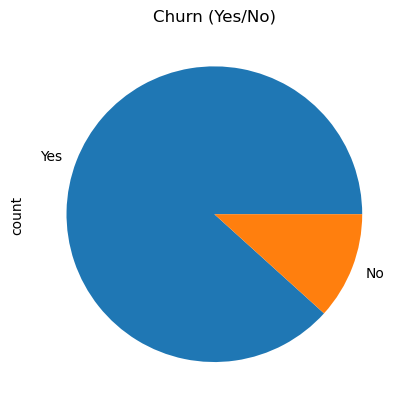

In [16]:
df["Churn"].value_counts().plot(kind="pie")
plt.title("Churn (Yes/No)")
plt.show()

In [17]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [18]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [19]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [20]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [21]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

In [22]:
df.groupby("ContractType")["MonthlyCharges"].mean()

ContractType
Month-to-Month    75.909198
One-Year          73.822803
Two-Year          71.334500
Name: MonthlyCharges, dtype: float64

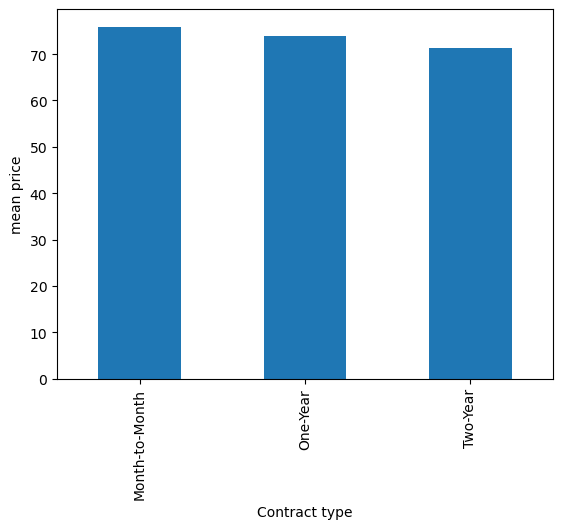

In [23]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.ylabel("mean price")
plt.xlabel("Contract type")
plt.show()

In [24]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


(array([105.,  94., 105., 108.,  93., 104., 114.,  81., 108.,  88.]),
 array([ 30.   ,  38.996,  47.992,  56.988,  65.984,  74.98 ,  83.976,
         92.972, 101.968, 110.964, 119.96 ]),
 <BarContainer object of 10 artists>)

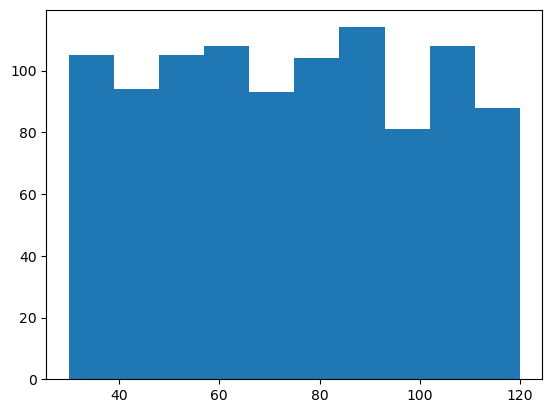

In [25]:
plt.hist(df["MonthlyCharges"])

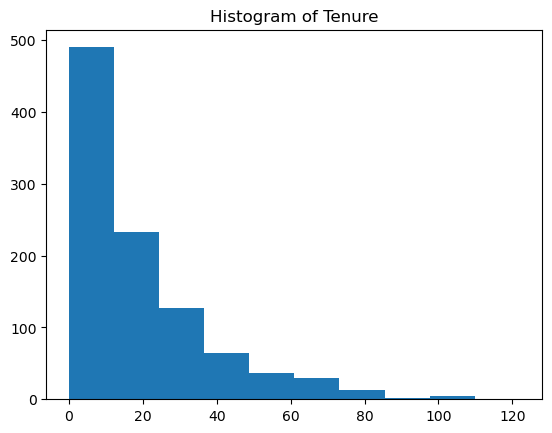

In [26]:
plt.hist(df["Tenure"])
plt.title("Histogram of Tenure")
plt.show()

In [27]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [28]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [29]:
df.head(1)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes


In [30]:
y = df[["Churn"]]
X = df[["Age","Gender","Tenure","MonthlyCharges"]]


In [31]:
y

,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
995,Yes
996,Yes
997,Yes
998,Yes


In [32]:
X["Gender"]

0        Male
1        Male
2      Female
3      Female
4        Male
        ...  
995      Male
996      Male
997    Female
998      Male
999      Male
Name: Gender, Length: 1000, dtype: object

In [33]:
X["Gender"].apply(lambda x: 1 if x == "Female" else 0)

0      0
1      0
2      1
3      1
4      0
      ..
995    0
996    0
997    1
998    0
999    0
Name: Gender, Length: 1000, dtype: int64

In [34]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [35]:
X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Female" else 0)


C:\Users\45mrm\AppData\Local\Temp\ipykernel_8548\558221084.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Female" else 0)


In [36]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [37]:
type(X["Gender"][0])

numpy.int64

In [38]:
y.head(2)

,Churn
0,Yes
1,Yes


In [39]:
X["Gender"].value_counts()

Gender
1    538
0    462
Name: count, dtype: int64

In [40]:
y

,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
995,Yes
996,Yes
997,Yes
998,Yes


In [41]:
y["Churn"] = y["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

C:\Users\45mrm\AppData\Local\Temp\ipykernel_8548\3691775968.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["Churn"] = y["Churn"].apply(lambda x: 1 if x == "Yes" else 0)


In [42]:
type(y["Churn"][0])

numpy.int64

In [43]:
y.value_counts()

Churn
1        883
0        117
Name: count, dtype: int64

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [46]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [47]:
print(X_test.dtypes)


Age                 int64
Gender              int64
Tenure              int64
MonthlyCharges    float64
dtype: object


In [48]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)





In [50]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [51]:
X_test  = scaler.fit_transform(X_test)

In [52]:
X_train

array([[ 1.45028506,  0.91601335, -0.27259374,  1.35228796],
       [-1.17649387, -1.09168714, -0.63553356, -0.57934868],
       [-1.07546391,  0.91601335, -0.73923066, -0.46357356],
       ...,
       [ 0.23792555,  0.91601335, -0.16889664, -0.52165344],
       [-0.26722424,  0.91601335, -0.58368502, -1.17053257],
       [-1.07546391,  0.91601335, -0.11704809,  1.54383616]])

In [53]:
X_test

array([[-1.04602196, -1.03046381, -0.69105701,  1.23992595],
       [-0.72548408,  0.97043679,  0.30158931,  1.63602859],
       [-1.47340581, -1.03046381,  1.00228083,  1.83878082],
       [ 0.66351342, -1.03046381, -0.51588413, -0.90573223],
       [-1.15286792, -1.03046381, -0.51588413, -0.36042684],
       [-0.83233004,  0.97043679,  0.53515315,  0.855269  ],
       [ 0.23612957, -1.03046381,  1.70297235, -0.49573125],
       [-0.19125427,  0.97043679, -0.28232029, -0.49450492],
       [-1.47340581,  0.97043679,  0.24319835,  0.6762257 ],
       [ 0.34297554,  0.97043679, -0.98301181,  0.22330338],
       [ 0.34297554, -1.03046381, -0.86622989, -1.34557376],
       [ 1.94566495,  0.97043679, -0.45749317,  0.66150981],
       [ 0.34297554,  0.97043679,  0.35998027, -1.79359078],
       [-1.58025177, -1.03046381, -0.69105701,  0.63044294],
       [-0.08440831, -1.03046381,  0.53515315,  0.8569041 ],
       [-1.04602196, -1.03046381,  0.71032603,  1.61722496],
       [-1.15286792,  0.

In [54]:
print(type(X_test))
print(X_test.shape)


<class 'numpy.ndarray'>
(200, 4)


In [55]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(y_test, predictions)))


In [56]:
from sklearn.model_selection import GridSearchCV

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
log_model = LogisticRegression()

In [59]:
import warnings 
warnings.filterwarnings("ignore")

In [60]:
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [62]:
log_model.predict([[40,0,20,80]])[0]

1

In [63]:
y_pred = log_model.predict(X_test)

In [64]:
modelperformance(y_pred)

Accuracy score on model is 0.905


In [65]:
from sklearn.neighbors import KNeighborsClassifier

In [66]:
param_grid = {
    "n_neighbors": [3,5,7,9],
    "weights": ["uniform","distance"]
}

In [67]:
gridkn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

In [68]:
gridkn.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,5


In [69]:
gridkn.best_params_

{'n_neighbors': 5, 'weights': 'distance'}

In [70]:
y_pred = gridkn.predict(X_test)

In [71]:
modelperformance(y_pred)

Accuracy score on model is 0.895


In [72]:
from sklearn.svm import SVC

In [73]:
svm = SVC()

In [74]:
param_grid = {
    "C" : [0.01,0.1,0.5,1],
    "kernel" : ["linear","rbf","poly"]
}

In [75]:
gridsvc = GridSearchCV(svm, param_grid, cv=5)

In [76]:
gridsvc.fit(X_train,y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [77]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [78]:
y_pred = gridsvc.predict(X_test)

In [79]:
modelperformance(y_pred)

Accuracy score on model is 0.905


In [80]:
from sklearn.tree import DecisionTreeClassifier

In [81]:
param_grid = {
    "criterion": ["gini","entropy"],
    "splitter": ["best","random"],
    "max_depth": [None, 10,20,30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [82]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)

In [83]:
grid_tree.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [84]:
grid_tree.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'splitter': 'random'}

In [85]:
y_pred = grid_tree.predict(X_test)

In [86]:
modelperformance(y_pred)

Accuracy score on model is 0.84


In [87]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()

In [88]:
param_grid = {
    "n_estimators": [32,64,128,256],
    "max_features": ["auto","sqrt","log2"],
    "bootstrap": [True, False]
}

In [89]:
grid_rfc = GridSearchCV(rfc_model, param_grid, cv=5)

In [90]:
grid_rfc.fit(X_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': ['auto', 'sqrt', ...], 'n_estimators': [32, 64, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,128


In [91]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 'sqrt', 'n_estimators': 128}

In [92]:
y_pred = grid_rfc.predict(X_test)

In [93]:
modelperformance(y_pred)

Accuracy score on model is 0.895


In [94]:
best_model = gridsvc.best_estimator_

In [95]:
joblib.dump(best_model, "model.pkl")

['model.pkl']